# Diffusion and flow matching
This notebook constructs manufactured diffusion targets on real digit images and trains a two-dimensional flow-matching field from explicit equations.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/18-diffusion/'
for _name in ['SklearnDigits.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset

torch.manual_seed(26521); np.random.seed(26521)
frame=pd.read_csv('SklearnDigits.csv'); X=frame.drop(columns='target').to_numpy(np.float32)/8-1
digits=torch.tensor(X)
digits.shape

torch.Size([1797, 64])

## Direct forward diffusion
A random time and Gaussian noise create both the input and the supervised noise target without simulating earlier steps.

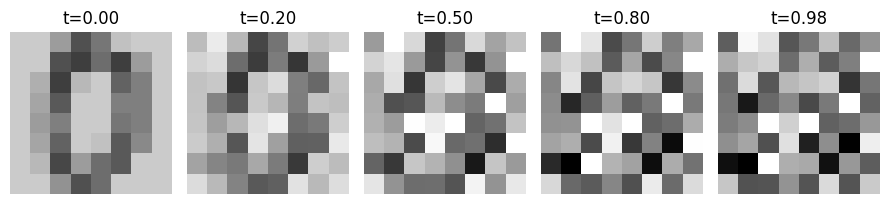

In [2]:
def alpha_bar(t): return torch.cos(torch.pi*t/2).square()
def corrupt(x,t,epsilon):
    a=alpha_bar(t)
    return torch.sqrt(a)*x+torch.sqrt(1-a)*epsilon

epsilon=torch.randn_like(digits[:1])
times=torch.tensor([[0.,.2,.5,.8,.98]]).T
noisy=torch.vstack([corrupt(digits[:1],t,epsilon) for t in times])
fig,axes=plt.subplots(1,5,figsize=(9,2))
for ax,image,t in zip(axes,noisy,times): ax.imshow(image.reshape(8,8),cmap='gray_r',vmin=-1.7,vmax=1.7); ax.set_title(f't={t.item():.2f}'); ax.axis('off')
plt.tight_layout()

## Noise predictor from the manufactured regression target
The network is deliberately small. Time is concatenated to the noisy image, and squared error predicts the sampled epsilon.

In [3]:
class NoisePredictor(nn.Module):
    def __init__(self):
        super().__init__(); self.net=nn.Sequential(nn.Linear(65,128),nn.SiLU(),nn.Linear(128,64))
    def forward(self,x,t): return self.net(torch.cat([x,t],dim=1))

model=NoisePredictor(); optimizer=torch.optim.Adam(model.parameters(),lr=2e-3)
loader=DataLoader(TensorDataset(digits),batch_size=128,shuffle=True)
losses=[]
for epoch in range(20):
    for (x0,) in loader:
        t=.02+.96*torch.rand(len(x0),1); eps=torch.randn_like(x0); xt=corrupt(x0,t,eps)
        loss=(model(xt,t)-eps).square().mean(); optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
losses[-5:]

[0.29149287939071655,
 0.34902629256248474,
 0.6101182699203491,
 0.28069373965263367,
 0.4367671608924866]

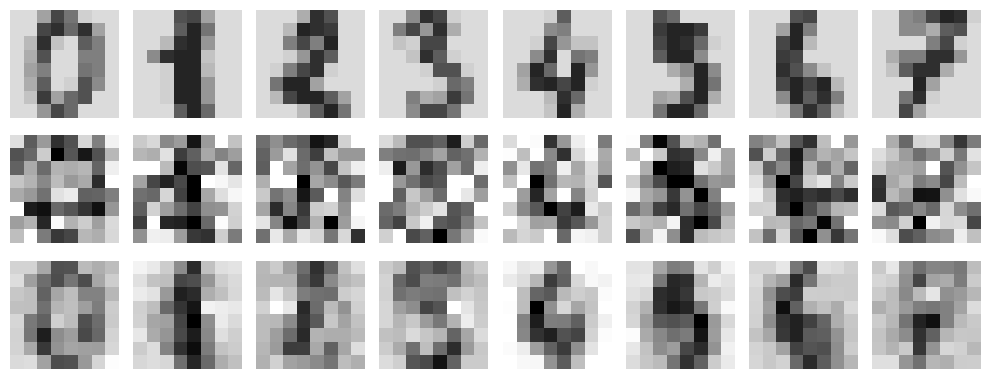

In [4]:
x0=digits[:8]; t=torch.full((8,1),.5); eps=torch.randn_like(x0); xt=corrupt(x0,t,eps)
with torch.no_grad(): eps_hat=model(xt,t); x0_hat=(xt-torch.sqrt(1-alpha_bar(t))*eps_hat)/torch.sqrt(alpha_bar(t))
fig,axes=plt.subplots(3,8,figsize=(10,4))
for j in range(8):
    for ax,image in zip(axes[:,j],[x0[j],xt[j],x0_hat[j]]): ax.imshow(image.reshape(8,8),cmap='gray_r',vmin=-1.4,vmax=1.4); ax.axis('off')
axes[0,0].set_ylabel('clean'); axes[1,0].set_ylabel('noisy'); axes[2,0].set_ylabel('estimate'); plt.tight_layout()

## Flow matching from straight endpoint paths
We create a two-moon target, pair it with Gaussian base samples, regress endpoint velocities, and integrate with Euler steps.

In [5]:
rng=np.random.default_rng(26521); n=1500; angle=rng.uniform(0,np.pi,n//2)
target=np.r_[np.c_[np.cos(angle),np.sin(angle)],np.c_[1-np.cos(angle),.45-np.sin(angle)]].astype('float32')
target+=rng.normal(scale=.06,size=target.shape).astype('float32')
target=torch.tensor(target)

class Velocity(nn.Module):
    def __init__(self): super().__init__(); self.net=nn.Sequential(nn.Linear(3,96),nn.Tanh(),nn.Linear(96,96),nn.Tanh(),nn.Linear(96,2))
    def forward(self,x,t): return self.net(torch.cat([x,t],dim=1))
field=Velocity(); optimizer=torch.optim.Adam(field.parameters(),lr=2e-3)
for step in range(1800):
    index=torch.randint(len(target),(256,)); x1=target[index]; x0=torch.randn_like(x1); t=torch.rand(len(x1),1)
    xt=(1-t)*x0+t*x1; velocity=x1-x0
    loss=(field(xt,t)-velocity).square().mean(); optimizer.zero_grad(); loss.backward(); optimizer.step()
loss.item()

1.0031275749206543

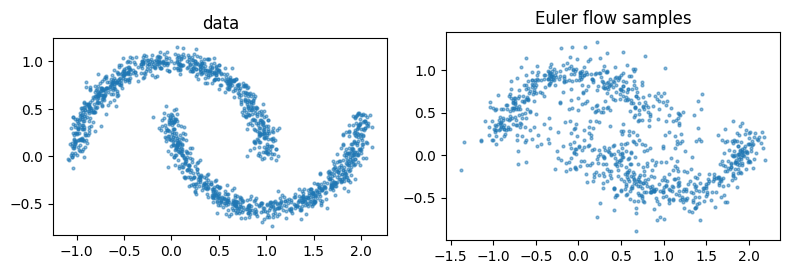

In [6]:
with torch.no_grad():
    sample=torch.randn(900,2); steps=60; dt=1/steps
    for k in range(steps): sample=sample+dt*field(sample,torch.full((len(sample),1),k/steps))
sample=sample.numpy()
fig,axes=plt.subplots(1,2,figsize=(8,3.4)); axes[0].scatter(target[:,0],target[:,1],s=4,alpha=.5); axes[0].set_title('data')
axes[1].scatter(sample[:,0],sample[:,1],s=4,alpha=.5); axes[1].set_title('Euler flow samples')
for ax in axes: ax.set_aspect('equal'); plt.tight_layout()